# Clasificación ABC-XYZ de inventario

**Objetivo:** clasificar los productos de un comercio minorista según **cuánto aportan a los ingresos (ABC)** y **qué tan estable es su demanda (XYZ)**, para proponer una política de inventario distinta para cada grupo.

**Datos:** [Online Retail II (UCI)](https://archive.ics.uci.edu/dataset/502/online+retail+ii): ~1 millón de transacciones de un comercio online del Reino Unido entre 2009 y 2011. Licencia CC BY 4.0.

## 1. Configuración y descarga de datos

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from download_data import download
from abc_xyz import load_raw, clean, abc_xyz, POLICIES

sns.set_theme(style="whitegrid")
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

xlsx_path = download()  # solo descarga la primera vez

Descargando Online Retail II desde UCI (~45 MB)...
Guardado en: /workspaces/inventory-abc-xyz-analysis/data/raw/online_retail_II.xlsx


## 2. Carga y limpieza

In [2]:
raw = load_raw(xlsx_path)
print(f"Filas originales: {len(raw):,}")
raw.head()

Filas originales: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df = clean(raw)
print(f"Filas después de limpiar: {len(df):,} ({len(df) / len(raw):.1%} del total)")
print(f"Productos (SKU): {df['StockCode'].nunique():,}")
print(f"Periodo: {df['InvoiceDate'].min():%Y-%m-%d} a {df['InvoiceDate'].max():%Y-%m-%d}")
print(f"Ingresos totales: £{df['Revenue'].sum():,.0f}")

Filas después de limpiar: 1,003,214 (94.0% del total)
Productos (SKU): 4,707
Periodo: 2009-12-01 a 2011-12-09
Ingresos totales: £19,642,692


**Reglas de limpieza:**
- Se eliminan las facturas de cancelación (empiezan por `C`), las cantidades o precios ≤ 0 y los duplicados.
- Se excluyen los códigos que no son productos (portes `POST`, ajustes, comisiones de Amazon, etc.).

## 3. Clasificación ABC-XYZ

- **ABC (valor):** A = SKUs que generan el primer 80 % de los ingresos, B = el siguiente 15 %, C = el 5 % restante.
- **XYZ (variabilidad):** coeficiente de variación (CV) de la demanda **semanal**. X = CV ≤ 0,5 (estable), Y = 0,5–1 (variable), Z = CV > 1 (errática).

In [4]:
result = abc_xyz(df, freq="W")
result.head(10)

,Description,Revenue,Units,Orders,RevenueShare,CumShare,ABC,MeanDemand,StdDemand,CV,XYZ,Class
StockCode,,,,,,,,,,,,
22423,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918,0.016830,0.016830,A,249.792453,180.239449,0.721557,Y,AY
85123A,WHITE HANGING HEART T-LIGHT HOLDER,261168.73,94719,5464,0.013296,0.030126,A,893.575472,563.146433,0.630217,Y,AY
85099B,JUMBO BAG RED WHITE SPOTTY,182680.98,97176,4013,0.009300,0.039426,A,916.754717,477.704057,0.521082,Y,AY
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,0.008577,0.048003,A,764.103774,7829.733748,10.246951,Z,AZ
47566,PARTY BUNTING,148318.28,28200,2674,0.007551,0.055554,A,266.037736,240.887311,0.905463,Y,AY
84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807,0.006584,0.062138,A,755.490566,697.711437,0.923521,Y,AY
22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018,0.005995,0.068133,A,330.981132,556.363920,1.680954,Z,AZ
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,0.004159,0.072292,A,736.160377,7171.231651,9.741399,Z,AZ
79321,CHILLI LIGHTS,80540.88,15841,1135,0.004100,0.076393,A,149.443396,191.419725,1.280884,Z,AZ


## 4. Curva de Pareto

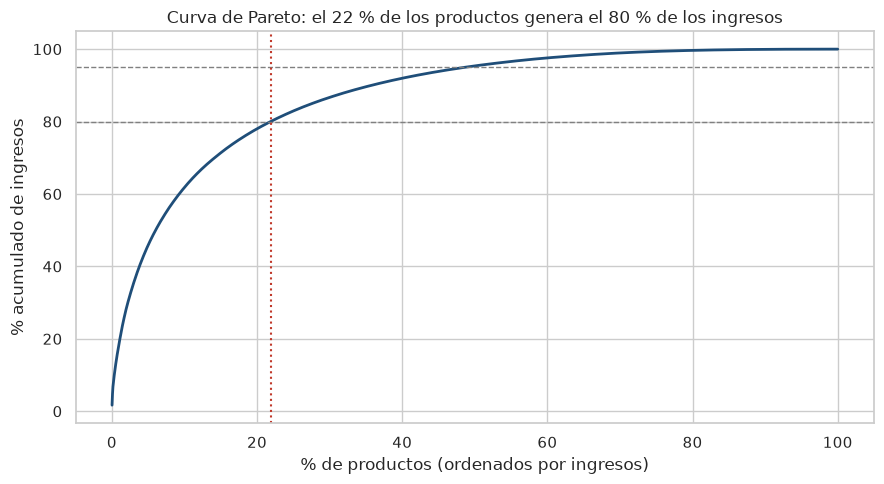

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(1, len(result) + 1)
ax.plot([i / len(result) * 100 for i in x], result["CumShare"] * 100, color="#1f4e79", lw=2)
ax.axhline(80, ls="--", color="grey", lw=1)
ax.axhline(95, ls="--", color="grey", lw=1)
share_a = (result["ABC"] == "A").mean() * 100
ax.axvline(share_a, ls=":", color="#c0392b", lw=1.5)
ax.set_xlabel("% de productos (ordenados por ingresos)")
ax.set_ylabel("% acumulado de ingresos")
ax.set_title(f"Curva de Pareto: el {share_a:.0f} % de los productos genera el 80 % de los ingresos")
fig.tight_layout()
fig.savefig(FIG_DIR / "pareto.png", dpi=150)
plt.show()

## 5. Matriz ABC-XYZ

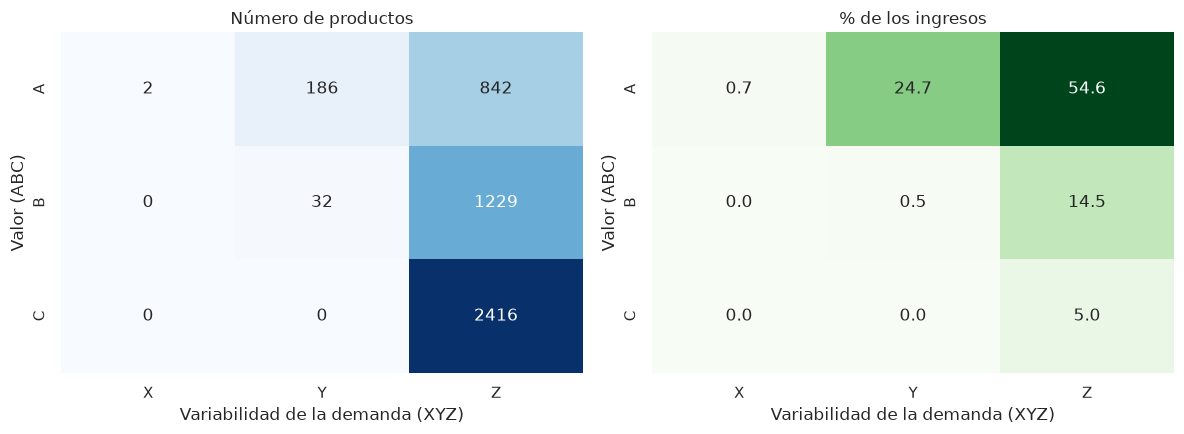

In [6]:
order_abc, order_xyz = ["A", "B", "C"], ["X", "Y", "Z"]
count_matrix = pd.crosstab(result["ABC"], result["XYZ"]).reindex(index=order_abc, columns=order_xyz, fill_value=0)
revenue_matrix = (
    result.pivot_table(index="ABC", columns="XYZ", values="RevenueShare", aggfunc="sum", fill_value=0)
    .reindex(index=order_abc, columns=order_xyz, fill_value=0) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(count_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Número de productos")
sns.heatmap(revenue_matrix, annot=True, fmt=".1f", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("% de los ingresos")
for ax in axes:
    ax.set_xlabel("Variabilidad de la demanda (XYZ)")
    ax.set_ylabel("Valor (ABC)")
fig.tight_layout()
fig.savefig(FIG_DIR / "abc_xyz_matrix.png", dpi=150)
plt.show()

## 6. Resumen por clase y política de inventario recomendada

In [7]:
summary = (
    result.groupby("Class")
    .agg(SKUs=("Revenue", "size"), Ingresos=("Revenue", "sum"), CV_medio=("CV", "mean"))
    .assign(PctSKUs=lambda t: t["SKUs"] / t["SKUs"].sum() * 100,
            PctIngresos=lambda t: t["Ingresos"] / t["Ingresos"].sum() * 100)
    .round({"Ingresos": 0, "CV_medio": 2, "PctSKUs": 1, "PctIngresos": 1})
)
summary["Política recomendada"] = summary.index.map(POLICIES)
summary

,SKUs,Ingresos,CV_medio,PctSKUs,PctIngresos,Política recomendada
Class,,,,,,
AX,2,132644.0,0.47,0.0,0.7,"Reposición automática, stock de seguridad bajo..."
AY,186,4855273.0,0.83,4.0,24.7,"Pronóstico con estacionalidad, stock de seguri..."
AZ,842,10729344.0,2.03,17.9,54.6,Seguimiento cercano con Compras; stock de segu...
BY,32,92055.0,0.86,0.7,0.5,Revisión periódica con pronóstico
BZ,1229,2851329.0,2.70,26.1,14.5,"Revisión periódica, evaluar comprar bajo pedido"
CZ,2416,982048.0,4.50,51.3,5.0,Candidato a descatalogar o vender solo bajo pe...


## 7. Exportar resultados

In [8]:
out_dir = ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)
result.to_csv(out_dir / "abc_xyz_por_sku.csv")
summary.to_csv(out_dir / "resumen_por_clase.csv")
print("Archivos guardados en data/processed/")

Archivos guardados en data/processed/


## 8. Conclusiones

Datos tras la limpieza: 1.003.214 filas (94,0 % del total), 4.707 productos, de 2009-12-01 a 2011-12-09, con ingresos totales de £19.642.692.

| Clase | Productos | % productos | Ingresos (£) | % ingresos | CV medio |
|---|---:|---:|---:|---:|---:|
| AX | 2 | 0,0 % | 132.644 | 0,7 % | 0,47 |
| AY | 186 | 4,0 % | 4.855.273 | 24,7 % | 0,83 |
| AZ | 842 | 17,9 % | 10.729.344 | 54,6 % | 2,03 |
| BY | 32 | 0,7 % | 92.055 | 0,5 % | 0,86 |
| BZ | 1.229 | 26,1 % | 2.851.329 | 14,5 % | 2,70 |
| CZ | 2.416 | 51,3 % | 982.048 | 5,0 % | 4,50 |

- **Concentración:** el **21,9 % de los productos** (1.030 SKUs de clase A) genera el **80 % de los ingresos**.
- **La demanda es muy errática:** el 95 % de los productos son Z. No hay ningún producto BX, CX ni CY.
- **Productos AX:** solo 2 (LUNCH BAG RED SPOTTY y JUMBO STORAGE BAG SUKI), que aportan el 0,7 % de los ingresos. Conviene automatizar su reposición.
- **Productos AY:** 186 productos con el 24,7 % de los ingresos. Incluyen los más vendidos: REGENCY CAKESTAND 3 TIER (£330.590), WHITE HANGING HEART T-LIGHT HOLDER (£261.169) y JUMBO BAG RED WHITE SPOTTY (£182.681). Conviene pronosticarlos teniendo en cuenta la estacionalidad.
- **Productos AZ:** 842 productos que concentran el 54,6 % de los ingresos con un CV medio de 2,03. Son el mayor riesgo de rotura de stock y requieren seguimiento cercano con Compras.
- **Productos CZ:** 2.416 productos (el 51,3 % del catálogo) que solo aportan el 5,0 % de los ingresos. Son candidatos a descatalogar o a vender solo bajo pedido para liberar capital y espacio.
- **Atención a los valores atípicos:** algunos productos tienen un CV muy alto porque sus ventas vienen de uno o pocos pedidos muy grandes (por ejemplo, PAPER CRAFT, LITTLE BIRDIE, con CV = 10,2, o MEDIUM CERAMIC TOP STORAGE JAR, con CV = 9,7). Tratar esos pedidos por separado podría cambiar su clase XYZ.

**Próximos pasos:** calcular el stock de seguridad y el punto de reorden por clase, tratar los pedidos atípicos y validar los resultados con un análisis por año (2010 vs. 2011).